<h3 align="center" style="color:green">Model Training</h3>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

training_df = pd.read_parquet("../DATA/model/train_df_for_model.parquet")
testing_df = pd.read_parquet("../DATA/model/test_df_for_model.parquet")

In [9]:
X_train = training_df.drop("default",axis=1)
X_test = testing_df.drop("default",axis=1)
y_train = training_df["default"]
y_test = testing_df["default"]


In [10]:
X_train.shape, y_train.shape

((33500, 16), (33500,))

In [11]:
X_test.shape, y_test.shape

((16500, 16), (16500,))

#### ATTEMPT :1

1. Logistic Regression, RandomForest & XGB
1. No handling of class imbalance

In [27]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import RandomUnderSampler





In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     15082
           1       0.83      0.73      0.78      1418

    accuracy                           0.96     16500
   macro avg       0.90      0.86      0.88     16500
weighted avg       0.96      0.96      0.96     16500



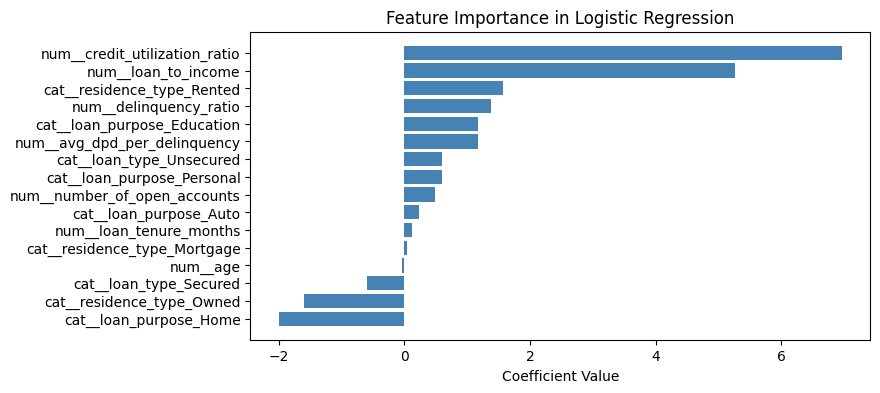

In [14]:
feature_importance = model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [ ]:

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     15082
           1       0.85      0.70      0.77      1418

    accuracy                           0.96     16500
   macro avg       0.91      0.85      0.87     16500
weighted avg       0.96      0.96      0.96     16500



In [ ]:

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     15082
           1       0.81      0.76      0.79      1418

    accuracy                           0.96     16500
   macro avg       0.90      0.87      0.88     16500
weighted avg       0.96      0.96      0.96     16500



Since there is not much difference between XGB and Logistic, we will choose LogisticRegression as a candidate for our RandomizedSearchCV candidate it has a better interpretation.

#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [23]:
param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'lbfgs', 'C': np.float64(78.47599703514607)}
Best Score: 0.7595935262229182
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     15082
           1       0.83      0.73      0.78      1418

    accuracy                           0.96     16500
   macro avg       0.90      0.86      0.88     16500
weighted avg       0.96      0.96      0.96     16500



#### RandomizedSearch CV for Attempt 1: XGBoost

In [25]:
# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.7882266976915199
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     15082
           1       0.76      0.84      0.80      1418

    accuracy                           0.96     16500
   macro avg       0.87      0.91      0.89     16500
weighted avg       0.97      0.96      0.96     16500



### Attempt 2

1. Logistic Regression & XGB
1. Handle Class Imbalance Using Under Sampling

In [28]:

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
y_train_res.value_counts()

default
0    2879
1    2879
Name: count, dtype: int64

In [29]:
model = LogisticRegression()
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     15082
           1       0.53      0.96      0.68      1418

    accuracy                           0.92     16500
   macro avg       0.76      0.94      0.82     16500
weighted avg       0.96      0.92      0.93     16500



In [31]:
model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     15082
           1       0.50      0.99      0.67      1418

    accuracy                           0.92     16500
   macro avg       0.75      0.95      0.81     16500
weighted avg       0.96      0.92      0.93     16500



### Attempt 3

1. Logistic Regression
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [32]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
y_train_smt.value_counts()

default
0    30578
1    30578
Name: count, dtype: int64

In [33]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     15082
           1       0.56      0.94      0.70      1418

    accuracy                           0.93     16500
   macro avg       0.77      0.94      0.83     16500
weighted avg       0.96      0.93      0.94     16500



In [35]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

c:\Users\naban\OneDrive\Desktop\PROJECT_CREDIT_RISK\creditproj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-05-15 00:15:20,901] A new study created in memory with name: no-name-8bbb4783-ddc1-4e84-afd8-bec8ae992908
[I 2026-05-15 00:15:25,153] Trial 0 finished with value: 0.9268631147554282 and parameters: {'C': 0.0005456569839940378, 'solver': 'saga', 'tol': 0.0010086252831189733, 'class_weight': None}. Best is trial 0 with value: 0.9268631147554282.
[I 2026-05-15 00:15:37,167] Trial 1 finished with value: 0.9458443206784266 and parameters: {'C': 1.2387142142393808, 'solver': 'saga', 'tol': 3.0821009237323474e-06, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9458443206784266.
[I 2026-05-15 00:15:39,950] Trial 2 finished with value: 0.9454683306058816 and parameters: {'C': 4.435119592216979, 'solver': 'lbfgs', 'tol': 0.00047141535615002, 'class_weight': None}. Best is trial 1 with value: 0.9458443206784266.
[I 2026-05-15 00:15:42,654] Trial 3 finished with value: 0.9342982938990371 and parameters: {'C': 2766.797624327105, 'solver': 'newton-cg', 'tol': 0.055704676616173156

In [37]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9458770317234219
  Params: 
    C: 1.3580882953756106
    solver: saga
    tol: 4.3791379171317867e-05
    class_weight: balanced
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     15082
           1       0.56      0.94      0.70      1418

    accuracy                           0.93     16500
   macro avg       0.78      0.94      0.83     16500
weighted avg       0.96      0.93      0.94     16500



c:\Users\naban\OneDrive\Desktop\PROJECT_CREDIT_RISK\creditproj\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Attempt 4

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [38]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-05-15 00:22:43,472] A new study created in memory with name: no-name-44559176-26f4-4331-b094-31e206676ec3
[I 2026-05-15 00:22:44,610] Trial 0 finished with value: 0.9518502361153547 and parameters: {'lambda': 0.003918468668152509, 'alpha': 9.932585919937477, 'subsample': 0.9398199615095622, 'colsample_bytree': 0.9491161674946014, 'max_depth': 5, 'eta': 0.052565291709072356, 'gamma': 7.314615588420107, 'scale_pos_weight': 2.4578026440366054, 'min_child_weight': 4, 'max_delta_step': 9}. Best is trial 0 with value: 0.9518502361153547.
[I 2026-05-15 00:22:45,808] Trial 1 finished with value: 0.8316096117375672 and parameters: {'lambda': 6.574438052302083, 'alpha': 4.185821849703503, 'subsample': 0.6332948305545483, 'colsample_bytree': 0.48418321697286326, 'max_depth': 6, 'eta': 0.012992017971541446, 'gamma': 1.8842779888523231, 'scale_pos_weight': 2.556104167620839, 'min_child_weight': 7, 'max_delta_step': 5}. Best is trial 0 with value: 0.9518502361153547.
[I 2026-05-15 00:22:46,6

In [39]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9766938042097931
  Params: 
    lambda: 0.0019377589786772262
    alpha: 0.3801944789231297
    subsample: 0.5457249946369751
    colsample_bytree: 0.858299262526218
    max_depth: 10
    eta: 0.19454671500956933
    gamma: 0.6545870859025436
    scale_pos_weight: 1.912955518319043
    min_child_weight: 2
    max_delta_step: 5
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     15082
           1       0.71      0.84      0.77      1418

    accuracy                           0.96     16500
   macro avg       0.85      0.90      0.87     16500
weighted avg       0.96      0.96      0.96     16500



## Model Evaluation : ROC/AUC

In [40]:
y_pred = best_model_logistic.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     15082
           1       0.56      0.94      0.70      1418

    accuracy                           0.93     16500
   macro avg       0.78      0.94      0.83     16500
weighted avg       0.96      0.93      0.94     16500



In [42]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.63042037e-05,
        6.63042037e-05]),
 array([0.        , 0.00070522, 0.1551481 , 0.1551481 , 0.15726375]),
 array([       inf, 1.        , 0.99950258, 0.99948727, 0.99948269]))

In [43]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9834141296970076

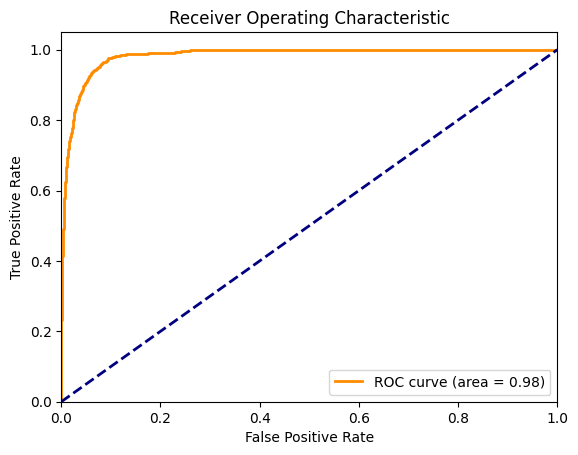

In [44]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Model Evaluation : Rankordering, KS statistic, Gini coeff

In [46]:
probabilities = best_model_logistic.predict_proba(X_test)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
0,0,0.007883
1,1,0.785365
2,0,0.010396


In [47]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
0,0,0.007883,6
1,1,0.785365,8
2,0,0.010396,6


In [48]:
df_eval[df_eval.Decile==8]['Default Probability'].describe()

count    1650.000000
mean        0.484443
std         0.185951
min         0.205561
25%         0.313153
50%         0.470410
75%         0.643746
max         0.820998
Name: Default Probability, dtype: float64

In [52]:
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))


In [53]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
}))
df_decile.reset_index(inplace=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.00,0.00,0.00,1650.00
1,1,0.00,0.00,0.00,1650.00
2,2,0.00,0.00,0.00,1650.00
3,3,0.00,0.00,0.00,1650.00
4,4,0.00,0.00,0.00,1650.00
5,5,0.00,0.00,0.00,1650.00
6,6,0.00,0.03,9.00,1641.00
7,7,0.03,0.21,12.00,1638.00
8,8,0.21,0.82,206.00,1444.00
9,9,0.82,1.00,1191.00,459.00


In [54]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.00,0.00,0.00,1650.00,0.00,100.00
1,1,0.00,0.00,0.00,1650.00,0.00,100.00
2,2,0.00,0.00,0.00,1650.00,0.00,100.00
3,3,0.00,0.00,0.00,1650.00,0.00,100.00
4,4,0.00,0.00,0.00,1650.00,0.00,100.00
5,5,0.00,0.00,0.00,1650.00,0.00,100.00
6,6,0.00,0.03,9.00,1641.00,0.55,99.45
7,7,0.03,0.21,12.00,1638.00,0.73,99.27
8,8,0.21,0.82,206.00,1444.00,12.48,87.52
9,9,0.82,1.00,1191.00,459.00,72.18,27.82


In [55]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.82,1.00,1191.00,459.00,72.18,27.82
1,8,0.21,0.82,206.00,1444.00,12.48,87.52
2,7,0.03,0.21,12.00,1638.00,0.73,99.27
3,6,0.00,0.03,9.00,1641.00,0.55,99.45
4,5,0.00,0.00,0.00,1650.00,0.00,100.00
5,4,0.00,0.00,0.00,1650.00,0.00,100.00
6,3,0.00,0.00,0.00,1650.00,0.00,100.00
7,2,0.00,0.00,0.00,1650.00,0.00,100.00
8,1,0.00,0.00,0.00,1650.00,0.00,100.00
9,0,0.00,0.00,0.00,1650.00,0.00,100.00


In [56]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.82,1.00,1191.00,459.00,72.18,27.82,1191.00,459.00
1,8,0.21,0.82,206.00,1444.00,12.48,87.52,1397.00,1903.00
2,7,0.03,0.21,12.00,1638.00,0.73,99.27,1409.00,3541.00
3,6,0.00,0.03,9.00,1641.00,0.55,99.45,1418.00,5182.00
4,5,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,6832.00
5,4,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,8482.00
6,3,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,10132.00
7,2,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,11782.00
8,1,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,13432.00
9,0,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,15082.00


In [57]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.82,1.00,1191.00,459.00,72.18,27.82,1191.00,459.00,83.99,3.04
1,8,0.21,0.82,206.00,1444.00,12.48,87.52,1397.00,1903.00,98.52,12.62
2,7,0.03,0.21,12.00,1638.00,0.73,99.27,1409.00,3541.00,99.37,23.48
3,6,0.00,0.03,9.00,1641.00,0.55,99.45,1418.00,5182.00,100.00,34.36
4,5,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,6832.00,100.00,45.30
5,4,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,8482.00,100.00,56.24
6,3,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,10132.00,100.00,67.18
7,2,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,11782.00,100.00,78.12
8,1,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,13432.00,100.00,89.06
9,0,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,15082.00,100.00,100.00


In [58]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.82,1.00,1191.00,459.00,72.18,27.82,1191.00,459.00,83.99,3.04,80.95
1,8,0.21,0.82,206.00,1444.00,12.48,87.52,1397.00,1903.00,98.52,12.62,85.90
2,7,0.03,0.21,12.00,1638.00,0.73,99.27,1409.00,3541.00,99.37,23.48,75.89
3,6,0.00,0.03,9.00,1641.00,0.55,99.45,1418.00,5182.00,100.00,34.36,65.64
4,5,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,6832.00,100.00,45.30,54.70
5,4,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,8482.00,100.00,56.24,43.76
6,3,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,10132.00,100.00,67.18,32.82
7,2,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,11782.00,100.00,78.12,21.88
8,1,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,13432.00,100.00,89.06,10.94
9,0,0.00,0.00,0.00,1650.00,0.00,100.00,1418.00,15082.00,100.00,100.00,0.00


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)

In [59]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9834141296970076
Gini Coefficient: 0.9668282593940152


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

#### Finalize The Model and Visualize Feature Importance

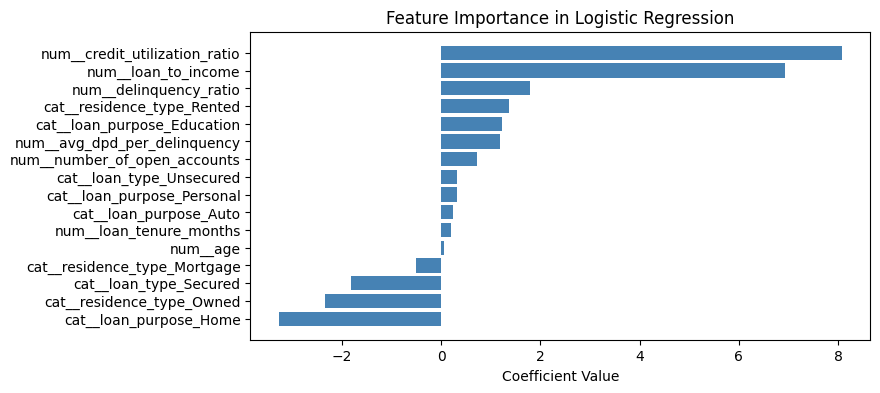

In [61]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

#### SAVING FINAL MODEL AND ARTIFACTS

In [72]:
X_train

,cat__loan_purpose_Auto,cat__loan_purpose_Education,cat__loan_purpose_Home,cat__loan_purpose_Personal,cat__loan_type_Secured,cat__loan_type_Unsecured,cat__residence_type_Mortgage,cat__residence_type_Owned,cat__residence_type_Rented,num__loan_tenure_months,num__age,num__number_of_open_accounts,num__credit_utilization_ratio,num__loan_to_income,num__delinquency_ratio,num__avg_dpd_per_delinquency
0,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,-0.63,-0.23,-0.50,0.78,-0.42,0.40,0.28
1,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.26,0.31,-1.00,-0.49,-0.07,6.03,0.40
2,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,-0.63,0.23,-1.00,-0.39,-0.31,1.52,0.30
3,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,-0.21,0.62,0.00,0.82,-0.33,-0.29,-0.75
4,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,1.26,-0.38,-1.00,-0.59,1.28,2.29,-0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33495,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.53,-0.31,0.50,-0.10,0.97,-0.29,-0.75
33496,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.89,1.31,-0.50,-0.59,-0.02,-0.29,-0.75
33497,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,-0.63,2.38,-0.50,-0.53,-0.35,-0.29,-0.75
33498,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.42,0.00,-1.00,0.10,-0.03,1.80,0.14


In [67]:
import pickle
cols_to_scale = pickle.load(open("../pickle_files/num_cols.pkl", "rb"))
features = X_train.columns
scaler = pickle.load(open("../pickle_files/scaler.pkl",'rb'))


In [ ]:
'age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', '', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'

In [ ]:
from joblib import dump

import pickle
cols_to_scale = pickle.load(open("../pickle_files/num_cols.pkl", "rb"))
features = X_train.columns


model_data = {
    'model': final_model,
    'features': features,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, '../artifacts/model_data.joblib')

['../artifacts/model_data.joblib']

In [70]:
final_model.coef_, final_model.intercept_

(array([[ 0.24273645,  1.22320956, -3.27197661,  0.3107565 , -1.80603061,
          0.3107565 , -0.50866901, -2.34663241,  1.36002731,  0.19816189,
          0.05644262,  0.7198876 ,  8.08205061,  6.93635462,  1.79104628,
          1.19196538]]),
 array([-6.75425453]))

In [74]:
# new cod

from joblib import dump
import pickle
pipeline = pickle.load(open("../pickle_files/pipeline.pkl",'rb'))



model_data = {

    "model": final_model,

    "pipeline": pipeline,

    "features": X_train.columns.tolist()
}


dump(
    model_data,
    "../app/artifacts/model_data.joblib"
)

['../app/artifacts/model_data.joblib']